In [7]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from pathlib import Path

In [8]:
RAW = Path("../data/raw") 
orders = pd.read_csv(RAW / "olist_orders_dataset.csv") 
customers = pd.read_csv(RAW / "olist_customers_dataset.csv") 
items = pd.read_csv(RAW / "olist_order_items_dataset.csv") 
payments = pd.read_csv(RAW / "olist_order_payments_dataset.csv") 
reviews = pd.read_csv(RAW / "olist_order_reviews_dataset.csv") 
products = pd.read_csv(RAW / "olist_products_dataset.csv") 
sellers = pd.read_csv(RAW / "olist_sellers_dataset.csv") 
geo = pd.read_csv(RAW / "olist_geolocation_dataset.csv") 
cat_trans = pd.read_csv(RAW / "product_category_name_translation.csv") 
dfs = {"orders":orders, "customers":customers, "items":items, "payments":payments, "reviews":reviews, "products":products, "sellers":sellers, "geo":geo, "cat_trans":cat_trans}

## Payment type breakdown

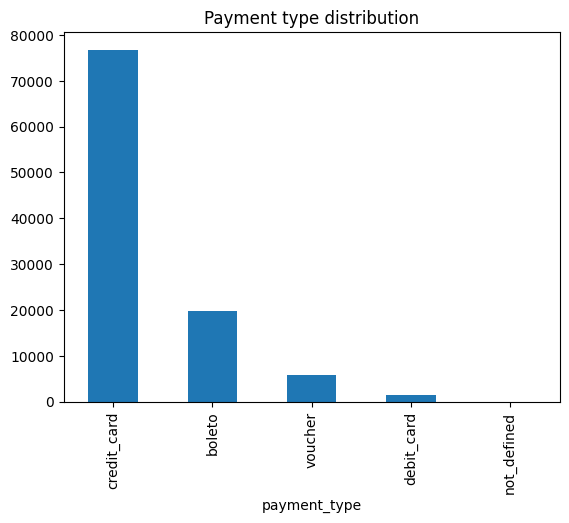

In [9]:
payments["payment_type"].value_counts().plot( kind="bar", title="Payment type distribution") 
plt.savefig("../reports/figures/1.3-payment-types.png", dpi=150) # Expect: credit_card dominant, boleto second, voucher small

## Revenue over time

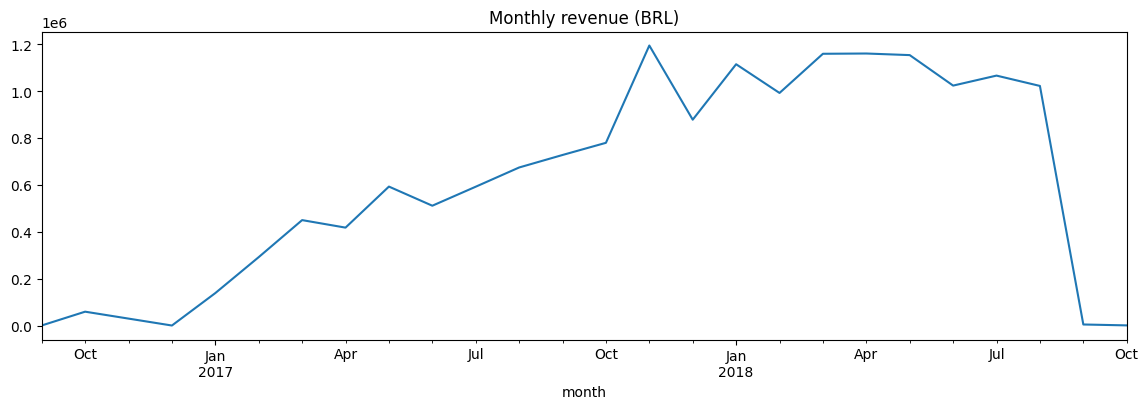

In [11]:
# Convert the column to datetime first
pay_orders = payments.merge(orders[["order_id","order_purchase_timestamp"]], on="order_id")
pay_orders["order_purchase_timestamp"] = pd.to_datetime(pay_orders["order_purchase_timestamp"])
pay_orders["month"] = pay_orders["order_purchase_timestamp"].dt.to_period("M")
monthly_rev = pay_orders.groupby("month")["payment_value"].sum()
monthly_rev.plot(title="Monthly revenue (BRL)", figsize=(14,4))
plt.savefig("../reports/figures/1.3-monthly-revenue.png", dpi=150)

## Installment analysis

Avg installments: 3.5


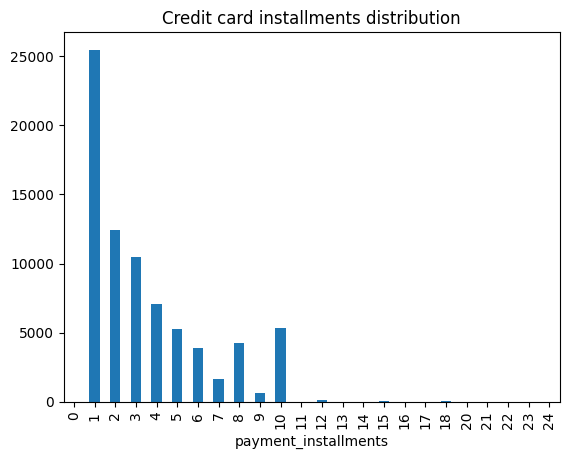

In [12]:
cc = payments[payments["payment_type"] == "credit_card"] 
cc["payment_installments"].value_counts().sort_index().plot( kind="bar", title="Credit card installments distribution")
plt.savefig("../reports/figures/1.3-installments.png", dpi=150) 
print(f"Avg installments: {cc['payment_installments'].mean():.1f}")